# EDA QA dataset cho RAG
Phân tích câu hỏi, answerability, QA type, source articles và độ khó tiềm năng đối với retrieval/generation.

In [1]:
from pathlib import Path
import json, ast, re
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "src" / "TEST_OUT" / "QWEN").exists():
    ROOT = ROOT.parent
if not (ROOT / "src" / "TEST_OUT" / "QWEN").exists():
    raise FileNotFoundError(f"Khong tim thay project root tu cwd: {Path.cwd()}")

QA_PATH = ROOT / "src" / "TEST_OUT" / "QWEN" / "data_QA_Convert.jsonl"
CORPUS = ROOT / "Dataset" / "Create_QA_Vietonline" / "VietOnlineNews"
if not CORPUS.exists():
    CORPUS = ROOT / "Dataset" / "Create_QA_Vietonline" / "VietOnlineNews_CSV"
if not CORPUS.exists():
    raise FileNotFoundError(f"Khong tim thay corpus: {CORPUS}")

rows = [json.loads(line) for line in QA_PATH.read_text(encoding="utf-8").splitlines() if line.strip()]
qa = pd.DataFrame(rows)

def as_list(x):
    if isinstance(x, list): return x
    if x is None or (isinstance(x, float) and np.isnan(x)): return []
    if isinstance(x, str):
        try:
            y = ast.literal_eval(x)
            return y if isinstance(y, list) else [y]
        except Exception: return [z.strip() for z in x.split(';') if z.strip()]
    return [x]

qa['question'] = qa.get('question', '').fillna('').astype(str)
qa['question_words'] = qa['question'].str.split().str.len()
qa['question_chars'] = qa['question'].str.len()
qa['qa_type'] = qa.get('qa_type', 'unknown').fillna('unknown').astype(str)
qa['is_possible_norm'] = qa.get('is_possible', pd.Series([np.nan] * len(qa))).map(lambda x: str(x).lower() if pd.notna(x) else 'unknown')

qa['source_ids_norm'] = qa.apply(
    lambda row: as_list(row.get('source_article_ids')) or as_list(row.get('article_id')),
    axis=1
)

qa['num_source_articles'] = qa['source_ids_norm'].str.len()

if 'answers' in qa:
    qa['answer_text'] = qa['answers'].map(lambda x: ' '.join(map(str, as_list(x))) if not isinstance(x, dict) else str(x))
else:
    qa['answer_text'] = ''

qa['answer_words'] = qa['answer_text'].fillna('').str.split().str.len()
qa['answerable'] = qa['is_possible_norm'].isin(['true', '1', 'yes'])

display(qa.head())
print('QA dataset:', QA_PATH)
print('Corpus:', CORPUS)
print('QA rows:', len(qa), '| Corpus articles:', len(news) if 'news' in globals() else 'chưa load')
print('Unique QA ids:', qa.get('id', pd.Series(dtype=str)).nunique(), '| Duplicate questions:', qa['question'].duplicated().sum())

,id,article_id,question,answers,is_possible,plausible_answers,qa_type,gold_id,source_article_ids,question_words,question_chars,is_possible_norm,source_ids_norm,num_source_articles,answer_text,answer_words,answerable
0,211640_1,211640,Những loại nội tạng động vật nào được khuyến c...,"[Gan, thận, lòng và dạ dày là các loại nội tạn...",True,[Tất cả nội tạng động vật nói chung đều nên tr...,factoid,[211640_token_0000],NaN,21,97,true,[211640],1,"Gan, thận, lòng và dạ dày là các loại nội tạng...",35,True
1,211640_2,211640,Quan niệm cho rằng thịt dê là thủ phạm duy nhấ...,[Thịt dê đúng là thịt đỏ có hàm lượng purin ca...,True,[Thịt dê thậm chí có thể chứa ít purin hơn một...,event_summary,[211640_token_0000],NaN,21,92,true,[211640],1,Thịt dê đúng là thịt đỏ có hàm lượng purin cao...,66,True
2,211640_3,211640,Tại sao nước dùng hầm xương hoặc nước lẩu lại ...,[Khi ninh hầm lâu hoặc nhúng lẩu nhiều nguyên ...,True,[Nước dùng hầm lâu còn có thể chứa nhiều chất ...,cause_effect,[211640_token_0000],NaN,16,70,true,[211640],1,Khi ninh hầm lâu hoặc nhúng lẩu nhiều nguyên l...,57,True
3,211640_4,211640,Hàm lượng purin trong cá nhỏ và nội tạng động ...,[Nội tạng động vật chứa lượng purin gấp 2-3 lầ...,True,[Mức purin cụ thể còn phụ thuộc vào cách chế b...,comparison,[211640_token_0000],NaN,21,95,true,[211640],1,Nội tạng động vật chứa lượng purin gấp 2-3 lần...,46,True
4,211640_5,211640,Đúng hay sai: 'Chỉ cần bỏ thịt dê và chuyển sa...,"[Sai. Nhiều loại hải sản như cá nhỏ (cá trích,...",True,[Một số loại hải sản có purin thấp hơn như cá ...,claim_verification,[211640_token_0000],NaN,22,95,true,[211640],1,"Sai. Nhiều loại hải sản như cá nhỏ (cá trích, ...",72,True


QA dataset: D:\HCMUS\HOCTAP\Semesters\25-26HK3\KhaiThacDuLieuVanBan\Project\Text-Mining---RAG-on-News\src\TEST_OUT\QWEN\data_QA_Convert.jsonl
Corpus: D:\HCMUS\HOCTAP\Semesters\25-26HK3\KhaiThacDuLieuVanBan\Project\Text-Mining---RAG-on-News\Dataset\Create_QA_Vietonline\VietOnlineNews
QA rows: 597 | Corpus articles: chưa load
Unique QA ids: 597 | Duplicate questions: 2


## Phân bố QA type, answerability và số bài nguồn

,questions,avg_question_words,avg_answer_words,answerable_rate,avg_sources
qa_type,,,,,
cause_effect,85,23.906,33.753,1.000,1.000
claim_verification,15,30.067,39.800,1.000,1.000
comparison,38,25.737,35.737,1.000,1.000
entity_role,75,23.893,39.653,1.000,1.000
event_summary,99,22.434,51.232,1.000,1.000
factoid,99,22.192,10.949,1.000,1.000
multi_doc_comparison,80,50.788,85.138,0.650,2.775
timeline,22,53.500,38.318,0.182,2.909
unanswerable,84,25.607,0.000,0.000,1.000


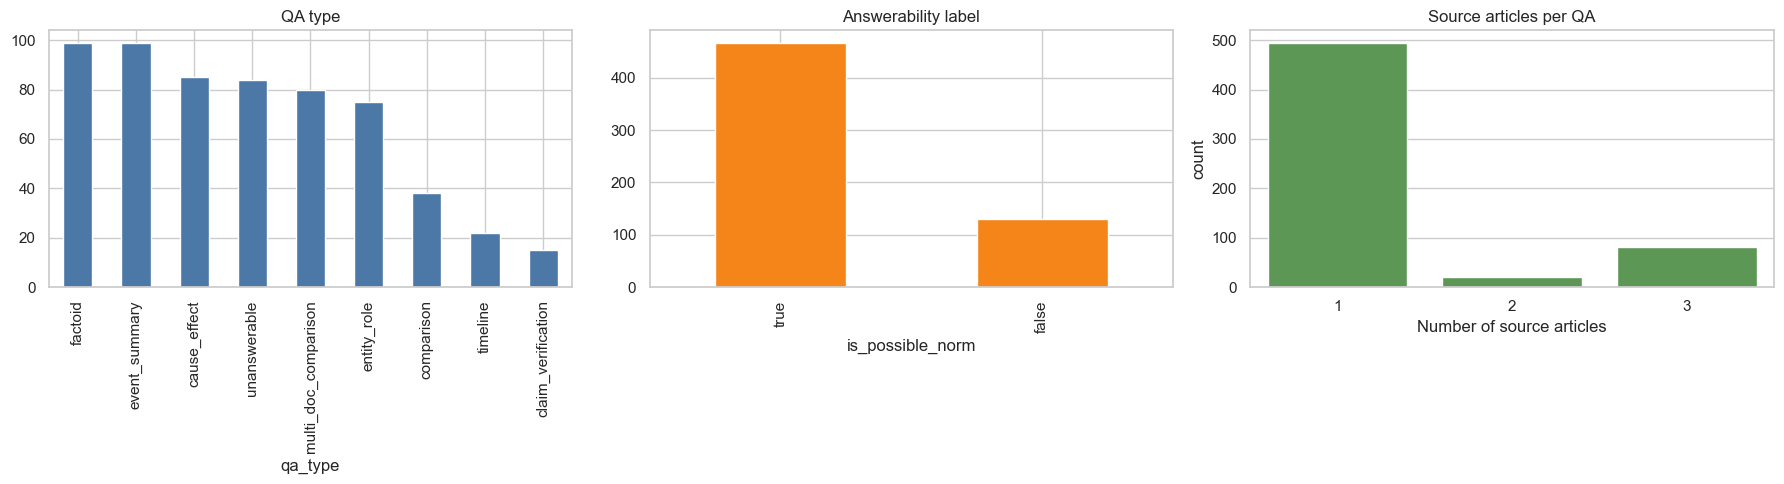

In [26]:
sns.set_theme(style='whitegrid')
fig,ax=plt.subplots(1,3,figsize=(18,5))
qa['qa_type'].value_counts().plot.bar(ax=ax[0],color='#4C78A8',title='QA type')
qa['is_possible_norm'].value_counts().plot.bar(ax=ax[1],color='#F58518',title='Answerability label')
sns.countplot(data=qa,x='num_source_articles',ax=ax[2],color='#54A24B'); ax[2].set_title('Source articles per QA'); ax[2].set_xlabel('Number of source articles')
plt.tight_layout()
display(qa.groupby('qa_type').agg(questions=('question','size'),avg_question_words=('question_words','mean'),avg_answer_words=('answer_words','mean'),answerable_rate=('answerable','mean'),avg_sources=('num_source_articles','mean')).round(3))

## Độ dài câu hỏi/câu trả lời và query difficulty proxies

,question_words,question_chars,answer_words,num_source_articles
count,597.00,597.00,597.00,597.00
mean,28.58,128.67,36.19,1.31
std,12.73,57.62,40.57,0.70
min,10.00,41.00,0.00,1.00
50%,25.00,113.00,30.00,1.00
90%,48.00,214.40,76.80,3.00
95%,56.00,249.00,130.00,3.00
99%,75.04,336.32,170.44,3.00
max,96.00,445.00,318.00,3.00


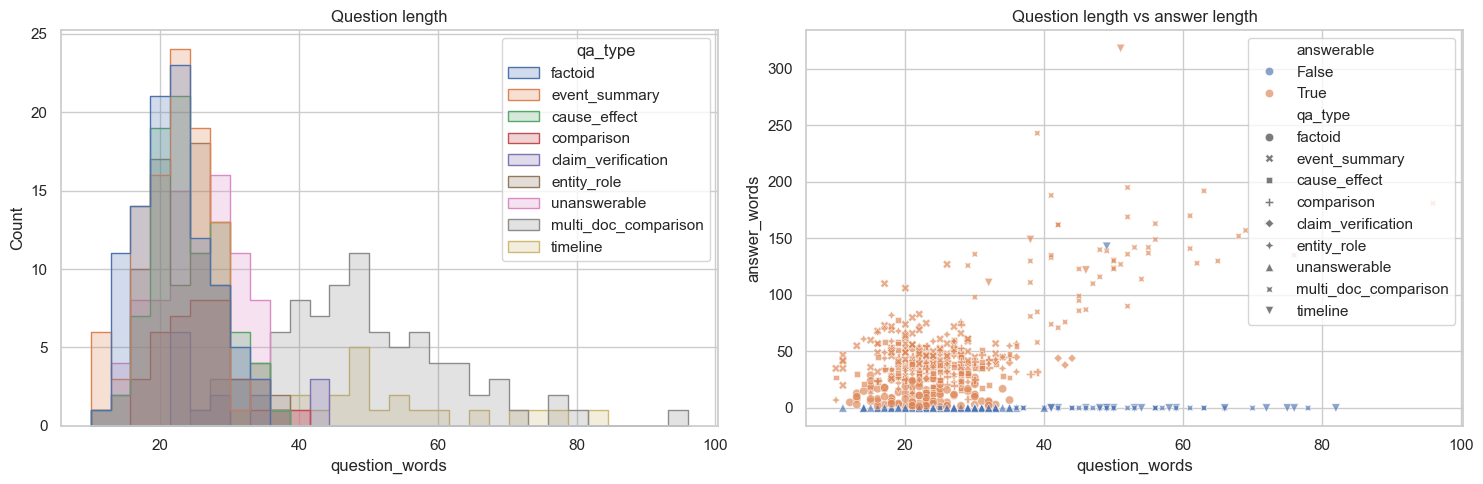

In [27]:
fig,ax=plt.subplots(1,2,figsize=(15,5))
sns.histplot(data=qa,x='question_words',hue='qa_type',bins=30,element='step',common_norm=False,ax=ax[0]); ax[0].set_title('Question length')
sns.scatterplot(data=qa,x='question_words',y='answer_words',hue='answerable',style='qa_type',alpha=.65,ax=ax[1]); ax[1].set_title('Question length vs answer length')
plt.tight_layout()
display(qa[['question_words','question_chars','answer_words','num_source_articles']].describe(percentiles=[.5,.9,.95,.99]).round(2))

## Kiểm tra liên kết QA với corpus và phát hiện QA bất thường

In [28]:
ids=set()
for split in ['train','validation','test']:
    for name in [f'{split}_new.csv', f'{split}.csv']:
        p=CORPUS/name
        if p.exists():
            ids.update(pd.read_csv(p,usecols=['id'])['id'].astype(str))
            break
qa['missing_source_id']=qa['source_ids_norm'].map(lambda xs:any(str(x) not in ids for x in xs))
print('QA có source article không tồn tại:',int(qa['missing_source_id'].sum()))
print('Câu hỏi rỗng:',int((qa['question'].str.strip()=='').sum()))
print('Answerable nhưng không có source:',int((qa['answerable'] & qa['num_source_articles'].eq(0)).sum()))
print('Potential duplicates:')
display(qa[qa['question'].duplicated(False)].sort_values('question')[['id','question','qa_type','source_ids_norm']].head(20))
print('Longest questions:')
display(qa.nlargest(10,'question_words')[['id','question','question_words','qa_type','num_source_articles']])

QA có source article không tồn tại: 0
Câu hỏi rỗng: 0
Answerable nhưng không có source: 0
Potential duplicates:


,id,question,qa_type,source_ids_norm
193,202551_2,Sự kiện chính được đề cập trong bài báo là gì?,event_summary,[202551]
248,215554_2,Sự kiện chính được đề cập trong bài báo là gì?,event_summary,[215554]
513,129210_2,Sự kiện chính được đề cập trong bài báo là gì?,event_summary,[129210]


Longest questions:


,id,question,question_words,qa_type,num_source_articles
581,cross_122101_122838_32239_1,So sánh sự thay đổi trong hỗ trợ quân sự phươn...,96,multi_doc_comparison,3
548,cross_149321_152478_701_2,Xét theo trình tự thời gian từ quý 1/2023 (khi...,82,timeline,3
100,cross_0_1,Theo các bài báo về phong thủy xây nhà năm Quý...,81,multi_doc_comparison,3
147,cross_23_2,"Xét về mặt giá bán, liệu mức giá của các mẫu x...",78,multi_doc_comparison,3
106,cross_3_1,So sánh chính sách thị thực của Trung Quốc đối...,76,multi_doc_comparison,3
139,cross_19_2,"Theo trình tự thời gian, hãy sắp xếp các sự ki...",76,timeline,3
117,cross_8_2,Xét theo dòng thời gian từ iPhone 17 Pro (2025...,75,timeline,3
549,cross_149561_152434_152829_1,"Dựa trên thông tin từ cả ba bài báo, hãy so sá...",72,multi_doc_comparison,3
582,cross_122101_122838_32239_2,"Từ ba bài báo, hãy phân tích trình tự suy yếu ...",72,timeline,3
101,cross_0_2,So sánh quan điểm của ba bài báo về các yếu tố...,70,multi_doc_comparison,3


## Keyword question type và export features

In [29]:
patterns={'who':r'\b(ai|người nào|nhân vật nào)\b','when':r'\b(khi nào|bao giờ|năm nào|ngày nào)\b','where':r'\b(ở đâu|tại đâu|nơi nào)\b','how_many':r'\b(bao nhiêu|mấy|số lượng)\b','why':r'\b(tại sao|vì sao|nguyên nhân)\b','what':r'\b(là gì|những gì|điều gì)\b'}
for name,pat in patterns.items(): qa[f'keyword_{name}']=qa['question'].str.lower().str.contains(pat,regex=True)
keyword_counts=pd.DataFrame({'feature':list(patterns),'count':[int(qa[f'keyword_{k}'].sum()) for k in patterns]})
display(keyword_counts.sort_values('count',ascending=False))
out = ROOT / 'src' / 'EDA_output'
out.mkdir(parents=True, exist_ok=True)
cols=['id','qa_type','question','question_words','question_chars','answer_words','num_source_articles','answerable','missing_source_id']+[f'keyword_{k}' for k in patterns]
qa[cols].to_csv(out/'qa_rag_features.csv',index=False)
print('Saved:',out/'qa_rag_features.csv')

C:\Users\TUAN ANH\AppData\Local\Temp\ipykernel_14272\2065902394.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  for name,pat in patterns.items(): qa[f'keyword_{name}']=qa['question'].str.lower().str.contains(pat,regex=True)


,feature,count
3,how_many,98
5,what,65
4,why,51
0,who,26
1,when,8
2,where,1


Saved: D:\HCMUS\HOCTAP\Semesters\25-26HK3\KhaiThacDuLieuVanBan\Project\Text-Mining---RAG-on-News\src\EDA_output\qa_rag_features.csv


## Coverage category của QA so với corpus
Join QA với article source để kiểm tra QA đã phủ hết category chưa và tỉ lệ theo category.

,category,corpus_articles,corpus_pct,qa_questions,qa_pct
3,Giải trí,2270,15.58,103,17.25
5,Kinh doanh,1853,12.72,73,12.23
9,Thể thao,1760,12.08,61,10.22
10,Thời sự,1485,10.19,68,11.39
2,Giáo dục,1241,8.52,58,9.72
4,Khoa học công nghệ,1089,7.47,48,8.04
11,Xe,1045,7.17,53,8.88
12,Đời sống,1014,6.96,28,4.69
7,Sức khỏe,928,6.37,38,6.37
8,Thế giới,853,5.85,28,4.69


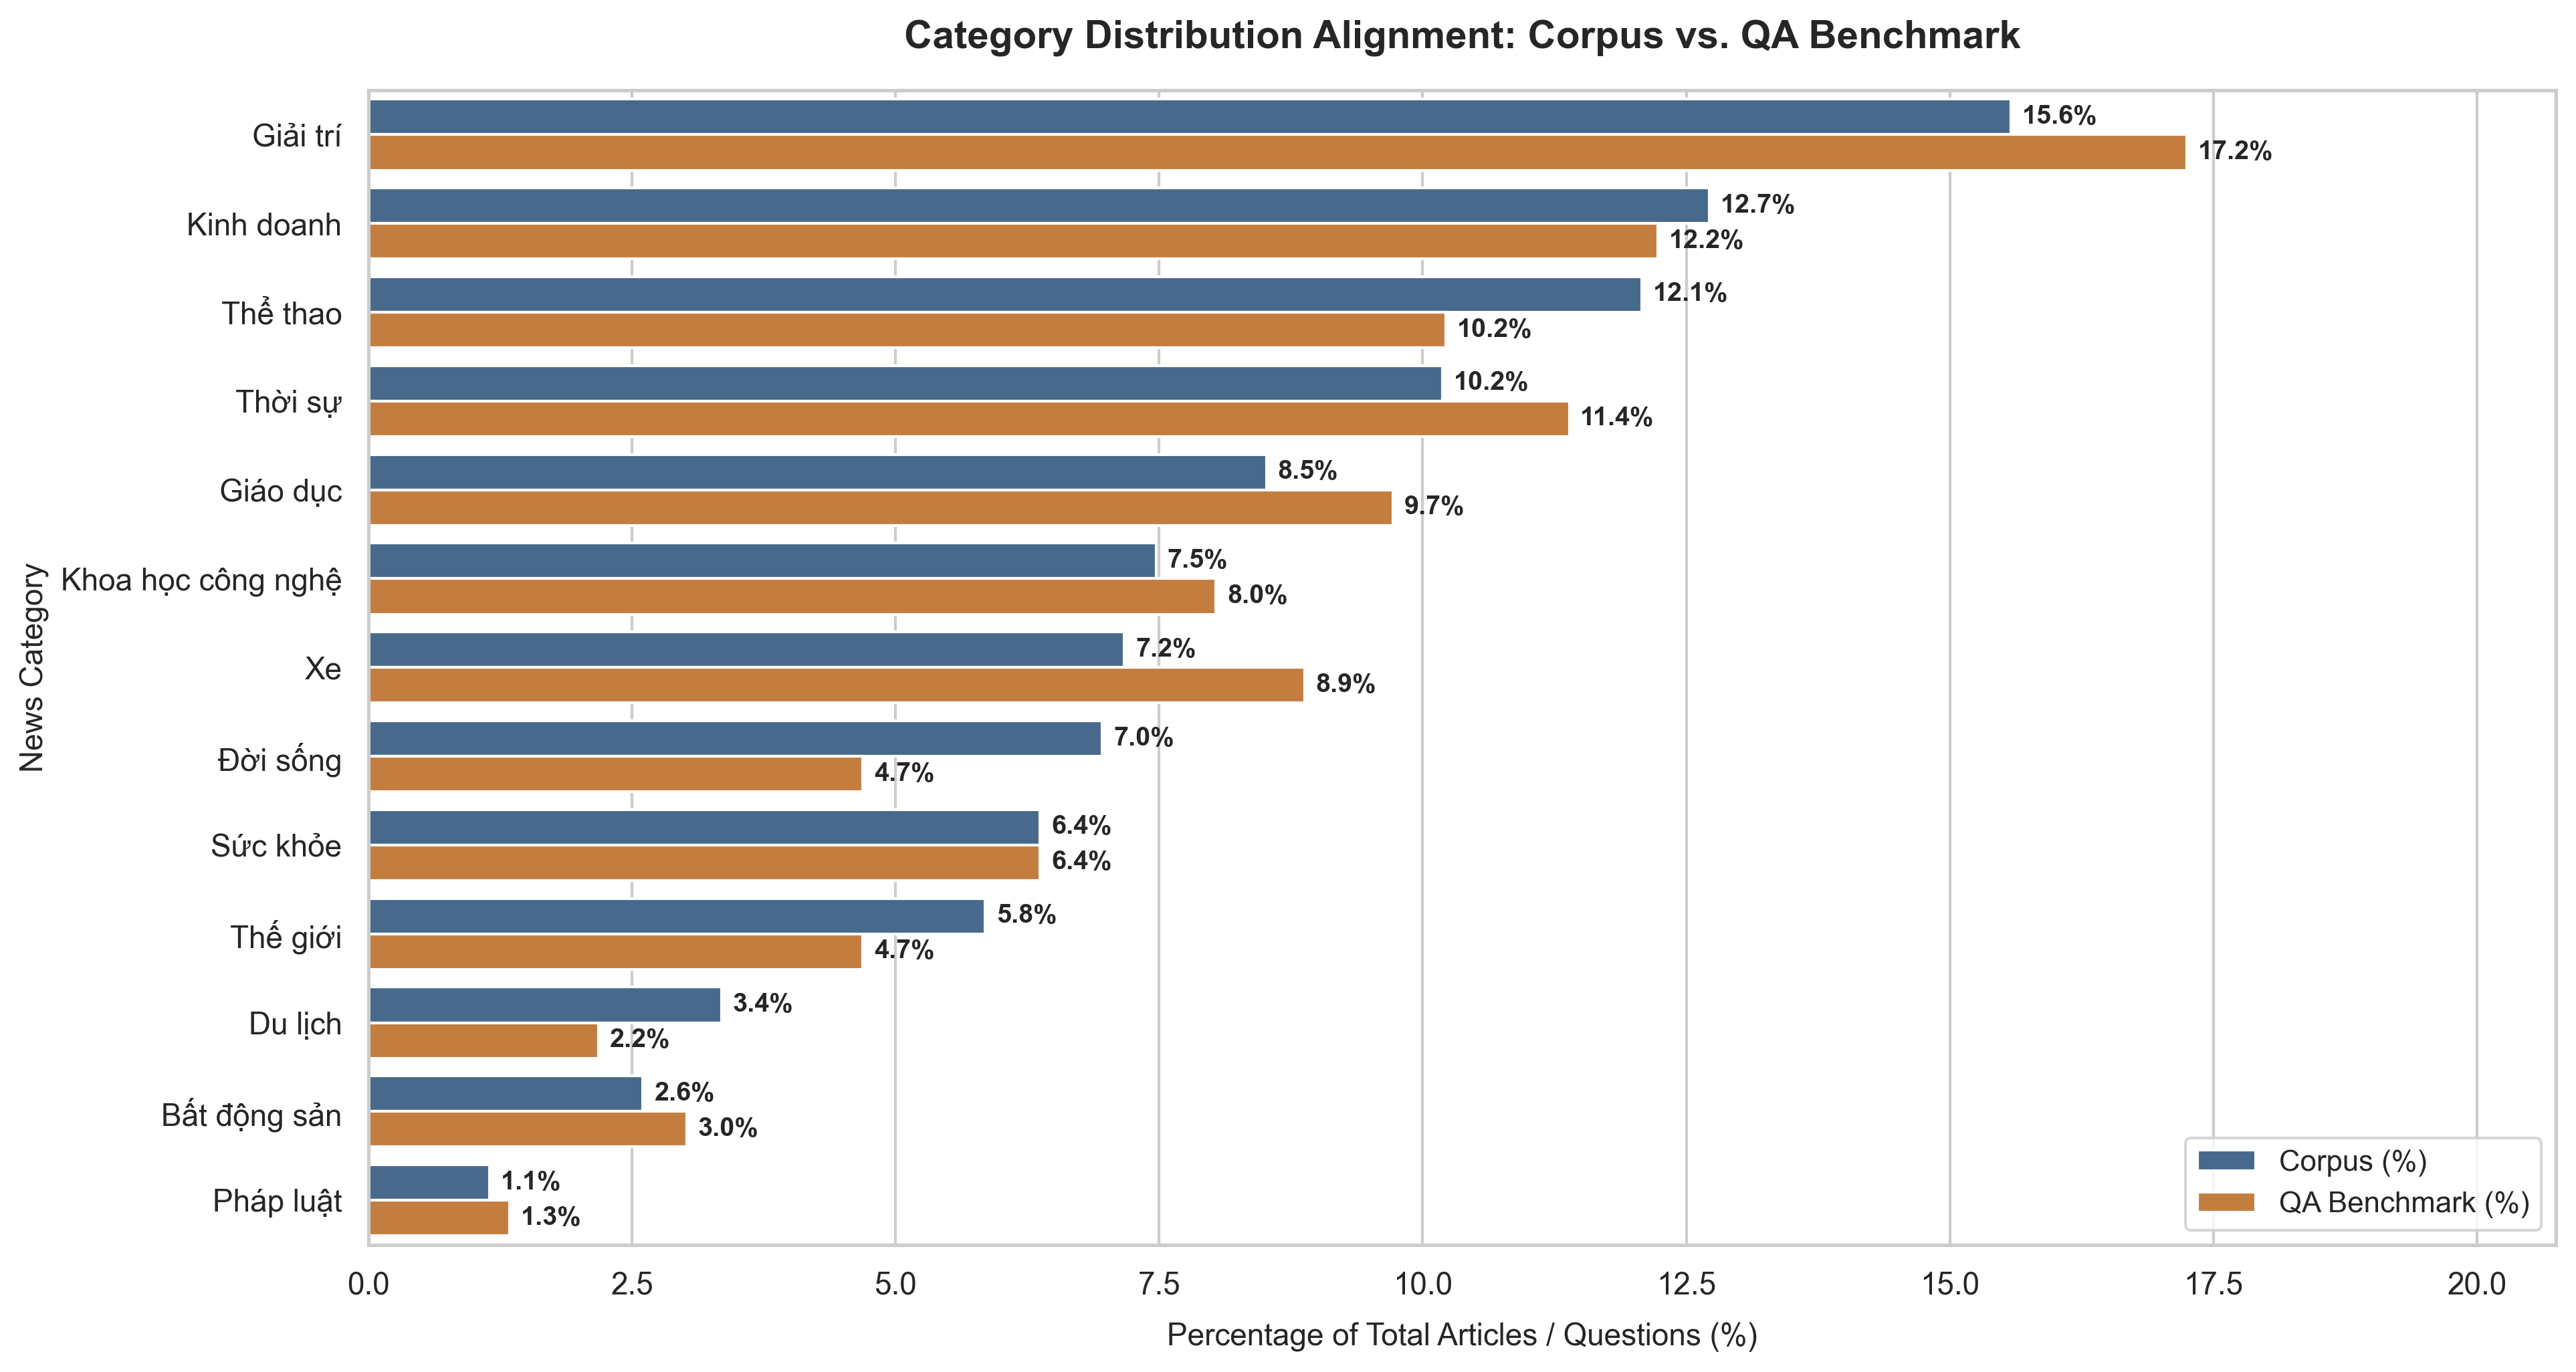

In [4]:
# parts=[]
# for split in ['train','validation','test']:
#     for name in [f'{split}_new.csv', f'{split}.csv']:
#         p=CORPUS/name
#         if p.exists():
#             x=pd.read_csv(p); x['split']=split; parts.append(x)
#             break
# news=pd.concat(parts,ignore_index=True) if parts else pd.DataFrame()
# for c in ['id','title','description','content','category']:
#     if c not in news: news[c]=''
# news['id_str']=news['id'].astype(str)
# news['category']=news['category'].fillna('(missing)').astype(str)
# news['content']=news['content'].fillna('').astype(str)
# id_to_category=dict(zip(news['id_str'],news['category']))
# id_to_content=dict(zip(news['id_str'],news['content']))
# id_to_title=dict(zip(news['id_str'],news['title'].fillna('').astype(str)))
# qa['source_category']=qa['source_ids_norm'].map(lambda xs:'; '.join(sorted({id_to_category.get(str(x),'(missing_source)') for x in xs})) if xs else '(no_source)')
# corpus_cat=news['category'].value_counts().rename_axis('category').reset_index(name='corpus_articles')
# corpus_cat['corpus_pct']=(corpus_cat['corpus_articles']/max(len(news),1)*100).round(2)
# qa_cat=qa['source_category'].value_counts().rename_axis('category').reset_index(name='qa_questions')
# qa_cat['qa_pct']=(qa_cat['qa_questions']/max(len(qa),1)*100).round(2)
# coverage=corpus_cat.merge(qa_cat,on='category',how='outer').fillna(0).sort_values(['qa_questions','corpus_articles'],ascending=False)
# display(coverage)
# print('Corpus categories:',news['category'].nunique(),'| QA source categories:',qa['source_category'].nunique())
# print('Categories in corpus but not QA:', sorted(set(corpus_cat['category'])-set(qa_cat['category'])))
# fig,ax=plt.subplots(1,2,figsize=(18,6))
# sns.barplot(data=corpus_cat.head(20),y='category',x='corpus_pct',ax=ax[0],color='#4C78A8'); ax[0].set_title('Corpus category %')
# sns.barplot(data=qa_cat,y='category',x='qa_pct',ax=ax[1],color='#F58518'); ax[1].set_title('QA source category %')
# plt.tight_layout()

parts = []
for split in ['train', 'validation', 'test']:
    for name in [f'{split}_new.csv', f'{split}.csv']:
        p = CORPUS / name
        if p.exists():
            x = pd.read_csv(p)
            x['split'] = split
            parts.append(x)
            break

news = pd.concat(parts, ignore_index=True) if parts else pd.DataFrame()
for c in ['id', 'title', 'description', 'content', 'category']:
    if c not in news:
        news[c] = ''
news['id_str'] = news['id'].astype(str)
news['category'] = news['category'].fillna('(missing)').astype(str)
news['content'] = news['content'].fillna('').astype(str)

id_to_category = dict(zip(news['id_str'], news['category']))
id_to_content = dict(zip(news['id_str'], news['content']))
id_to_title = dict(zip(news['id_str'], news['title'].fillna('').astype(str)))

qa['source_category'] = qa['source_ids_norm'].map(
    lambda xs: '; '.join(sorted({id_to_category.get(str(x), '(missing_source)') for x in xs})) if xs else '(no_source)'
)

corpus_cat = news['category'].value_counts().rename_axis('category').reset_index(name='corpus_articles')
corpus_cat['corpus_pct'] = (corpus_cat['corpus_articles'] / max(len(news), 1) * 100).round(2)

qa_cat = qa['source_category'].value_counts().rename_axis('category').reset_index(name='qa_questions')
qa_cat['qa_pct'] = (qa_cat['qa_questions'] / max(len(qa), 1) * 100).round(2)

# Merge and sort descending by Corpus percentage
coverage = corpus_cat.merge(qa_cat, on='category', how='outer').fillna(0).sort_values('corpus_pct', ascending=False)
display(coverage)

# --- Reshape to Long-Form for Grouped Bar Chart ---
plot_df = coverage.melt(
    id_vars=['category'],
    value_vars=['corpus_pct', 'qa_pct'],
    var_name='Source',
    value_name='Percentage'
)
plot_df['Source'] = plot_df['Source'].map({'corpus_pct': 'Corpus (%)', 'qa_pct': 'QA Benchmark (%)'})

# --- Plot Configuration (English Titles & Labels) ---
fig, ax = plt.subplots(figsize=(13, 7), dpi=300)
sns.set_theme(style='whitegrid', font='sans-serif')

bar_plot = sns.barplot(
    data=plot_df,
    y='category',
    x='Percentage',
    hue='Source',
    palette=['#3b6998', '#d97b29'],
    ax=ax
)

# Add Data Labels on top of each bar
for p in bar_plot.patches:
    val = p.get_width()
    if val > 0:
        ax.annotate(
            f"{val:.1f}%",
            (val, p.get_y() + p.get_height() / 2),
            ha='left',
            va='center',
            xytext=(4, 0),
            textcoords='offset points',
            fontsize=9.5,
            fontweight='semibold'
        )

ax.set_title('Category Distribution Alignment: Corpus vs. QA Benchmark', fontsize=14, pad=15, fontweight='bold')
ax.set_xlabel('Percentage of Total Articles / Questions (%)', fontsize=11, labelpad=8)
ax.set_ylabel('News Category', fontsize=11)
ax.set_xlim(0, max(plot_df['Percentage']) + 3.5)
ax.legend(title='', loc='lower right', frameon=True, fontsize=10.5)

plt.tight_layout()
plt.savefig('qa_corpus_category_coverage.png', bbox_inches='tight')
plt.show()

## Answer nằm trong paragraph/chunk nào?
Kiểm tra answer exact match trong article paragraph và trong các chunk đã tạo.

In [21]:
def norm_text(s): return ' '.join(str(s or '').lower().split())
def answer_text_from_row(row): return str(row.get('answer_text','')).strip()
def answer_article_scope(row):
    ans=norm_text(answer_text_from_row(row))
    if not row.get('answerable',False) or not ans: return 'unanswerable_or_empty'
    for aid in row['source_ids_norm']:
        content=id_to_content.get(str(aid),'')
        paragraphs=[p.strip() for p in re.split(r'\n\s*\n+', content) if p.strip()]
        for para in paragraphs:
            if ans in norm_text(para): return 'single_paragraph'
        if ans in norm_text(content): return 'article_multi_paragraph_or_spacing'
    return 'not_exact_in_source'
qa['answer_article_scope']=qa.apply(answer_article_scope,axis=1)
display(qa['answer_article_scope'].value_counts().rename_axis('scope').reset_index(name='count').assign(pct=lambda d:(d['count']/len(qa)*100).round(2)))
chunk_rows=[]
for path in (ROOT/'src'/'chunking'/'output').glob('*.jsonl'):
    method=path.stem.replace('vieonline_news_chunks_','')
    chunks=[json.loads(line) for line in path.read_text(encoding='utf-8').splitlines() if line.strip()]
    article_to_chunks={}
    for ch in chunks: article_to_chunks.setdefault(str(ch.get('article_id')),[]).append(ch)
    hit_count=multi_count=0
    for _,row in qa.iterrows():
        ans=norm_text(answer_text_from_row(row))
        if not row['answerable'] or not ans: continue
        hits=[]
        for aid in row['source_ids_norm']:
            for ch in article_to_chunks.get(str(aid),[]):
                if ans in norm_text(ch.get('text','')): hits.append(ch.get('chunk_id'))
        if hits:
            hit_count+=1
            if len(set(hits))>1: multi_count+=1
    chunk_rows.append({'chunk_method':method,'answerable_questions':int(qa['answerable'].sum()),'answer_exact_in_any_chunk':hit_count,'pct':round(hit_count/max(int(qa['answerable'].sum()),1)*100,2),'matched_multiple_chunks':multi_count})
display(pd.DataFrame(chunk_rows).sort_values('pct',ascending=False))

,scope,count,pct
0,not_exact_in_source,424,71.02
1,unanswerable_or_empty,130,21.78
2,single_paragraph,43,7.20


,chunk_method,answerable_questions,answer_exact_in_any_chunk,pct,matched_multiple_chunks
1,llamaindex,467,43,9.21,11
3,token,467,43,9.21,5
0,langchain_recursive,467,41,8.78,9
2,structured,467,39,8.35,6


In [23]:
check = qa[
    (qa['answerable']) &
    (qa['answer_article_scope'] == 'not_exact_in_source')
][['id','question','answer_text','source_ids_norm']].head(10)

display(check)

,id,question,answer_text,source_ids_norm
0,211640_1,Những loại nội tạng động vật nào được khuyến c...,"Gan, thận, lòng và dạ dày là các loại nội tạng...",[211640]
1,211640_2,Quan niệm cho rằng thịt dê là thủ phạm duy nhấ...,Thịt dê đúng là thịt đỏ có hàm lượng purin cao...,[211640]
2,211640_3,Tại sao nước dùng hầm xương hoặc nước lẩu lại ...,Khi ninh hầm lâu hoặc nhúng lẩu nhiều nguyên l...,[211640]
3,211640_4,Hàm lượng purin trong cá nhỏ và nội tạng động ...,Nội tạng động vật chứa lượng purin gấp 2-3 lần...,[211640]
4,211640_5,Đúng hay sai: 'Chỉ cần bỏ thịt dê và chuyển sa...,"Sai. Nhiều loại hải sản như cá nhỏ (cá trích, ...",[211640]
5,152685_1,Doanh nghiệp nào trúng đấu giá thuê khu đất ve...,"Công ty TNHH Đầu tư và Vận tải An Phú Minh, có...",[152685]
6,152685_2,Cuộc đấu giá cho thuê khu đất số 5 Lê Lợi ven ...,Công ty TNHH Đầu tư và Vận tải An Phú Minh trú...,[152685]
7,152685_3,Vì sao dư luận bất ngờ khi biết danh tính doan...,Vì Công ty An Phú Minh mới thành lập khoảng 18...,[152685]
8,152685_4,Khu đất số 5 Lê Lợi được đưa ra đấu giá nhằm p...,Khu đất được đấu giá cho thuê nhằm kêu gọi doa...,[152685]
10,132354_1,Ông Nghiêm Xuân Thành đến kiểm tra công tác ứn...,Ông đến kiểm tra tại các địa điểm xung yếu ở P...,[132354]


In [24]:
for _, row in check.iterrows():
    print('=' * 100)
    print('QUESTION:', row['question'])
    print('ANSWER:', row['answer_text'])
    print('SOURCE:', row['source_ids_norm'])
    for aid in row['source_ids_norm']:
        print('ARTICLE:', id_to_title.get(str(aid), '(not found)'))
        print(id_to_content.get(str(aid), '')[:2000])

QUESTION: Những loại nội tạng động vật nào được khuyến cáo nên hạn chế để tránh tăng axit uric và hại thận?
ANSWER: Gan, thận, lòng và dạ dày là các loại nội tạng chứa lượng purin rất cao, cần hạn chế hoặc tránh, đặc biệt với người trung niên, cao tuổi hoặc có nguy cơ bệnh thận.
SOURCE: [211640]
ARTICLE: Không muốn hại thận, cần hạn chế 4 loại thịt
TheoSohu, nhiều người khi nhắc đến tăng axit uric, gout hay tổn thương thận thường lập tức đổ lỗi cho thịt dê, cho rằng cứ ăn thịt dê là axit uric tăng vọt, khớp sưng đau. Thực tế, coi thịt dê là “thủ phạm duy nhất” là không chính xác nhưng đây đúng là một loại thịt đỏ có hàm lượng purin cao, cần hạn chế tiêu thụ. Thịt dêđược xếp vào nhóm thịt đỏ nên purin cao hơn thịt trắng. Khi purin được chuyển hóa thành axit uric, thận phải tăng cường lọc và đào thải. Nếu thận không xử lý kịp, axit uric tích tụ, lắng đọng tại khớp hoặc ảnh hưởng đến thận. Với người vốn có tốc độ chuyển hóa chậm, một bữa lẩu thịt dê có thể khiến lượng purin tăng mạnh và a

## Duplicate g?n tr?ng v? lexical overlap
Phát hiện câu hỏi g?n tr?ng và câu hỏi có khả năng copy lexical từ source document.

In [25]:
from difflib import SequenceMatcher

pairs=[]; questions=qa['question'].fillna('').astype(str).tolist()
for i in range(len(questions)):
    for j in range(i+1,len(questions)):
        score=SequenceMatcher(None,norm_text(questions[i]),norm_text(questions[j])).ratio()
        if score>=0.85:
            pairs.append({'id_1':qa.iloc[i].get('id',i),'id_2':qa.iloc[j].get('id',j),'similarity':round(score,3),'question_1':questions[i],'question_2':questions[j]})

near_dup=pd.DataFrame(pairs).sort_values('similarity',ascending=False) if pairs else pd.DataFrame(columns=['id_1','id_2','similarity','question_1','question_2'])

print('Near-duplicate question pairs similarity >= 0.85:',len(near_dup))
display(near_dup.head(30))

out=ROOT/'src'/'EDA_output'
out.mkdir(parents=True,exist_ok=True)

near_dup.to_csv(out/'qa_near_duplicate_questions.csv',index=False)

qa[['id','article_id','question','qa_type','answerable','question_words','question_chars','answer_words','num_source_articles']].to_csv(out/'qa_rag_deep_checks.csv',index=False)

print('Saved:',out)

Near-duplicate question pairs similarity >= 0.85: 10


,id_1,id_2,similarity,question_1,question_2
6,202551_2,129210_2,1.000,Sự kiện chính được đề cập trong bài báo là gì?,Sự kiện chính được đề cập trong bài báo là gì?
4,202551_2,215554_2,1.000,Sự kiện chính được đề cập trong bài báo là gì?,Sự kiện chính được đề cập trong bài báo là gì?
8,215554_2,129210_2,1.000,Sự kiện chính được đề cập trong bài báo là gì?,Sự kiện chính được đề cập trong bài báo là gì?
9,185632_2,129210_2,0.957,Sự việc chính được đề cập trong bài báo là gì?,Sự kiện chính được đề cập trong bài báo là gì?
7,215554_2,185632_2,0.957,Sự kiện chính được đề cập trong bài báo là gì?,Sự việc chính được đề cập trong bài báo là gì?
5,202551_2,185632_2,0.957,Sự kiện chính được đề cập trong bài báo là gì?,Sự việc chính được đề cập trong bài báo là gì?
1,134838_2,215554_2,0.955,Sự kiện chính được đề cập trong bài là gì?,Sự kiện chính được đề cập trong bài báo là gì?
0,134838_2,202551_2,0.955,Sự kiện chính được đề cập trong bài là gì?,Sự kiện chính được đề cập trong bài báo là gì?
3,134838_2,129210_2,0.955,Sự kiện chính được đề cập trong bài là gì?,Sự kiện chính được đề cập trong bài báo là gì?
2,134838_2,185632_2,0.909,Sự kiện chính được đề cập trong bài là gì?,Sự việc chính được đề cập trong bài báo là gì?


Saved: D:\HCMUS\HOCTAP\Semesters\25-26HK3\KhaiThacDuLieuVanBan\Project\Text-Mining---RAG-on-News\src\EDA_output


## Tuấn Anh không tính lại Recall@5

## Recall@5 theo category
T?nh Recall@5 cho embedding v? reranker theo category c?a gold article.

Missing: D:\HCMUS\HOCTAP\Semesters\25-26HK3\KhaiThacDuLieuVanBan\Project\Text-Mining---RAG-on-News\src\re-ranker\output_Rerank\rerank_token_bge_top5.jsonl


,category,questions,recall_at_5,pipeline
0,(missing_source),29,0.0,embedding_token
1,Bất động sản,9,0.0,embedding_token
2,Du lịch,4,0.0,embedding_token
3,Giáo dục,9,0.0,embedding_token
4,Giải trí,17,0.0,embedding_token
5,Khoa học công nghệ,9,0.0,embedding_token
6,Kinh doanh,4,0.0,embedding_token
7,Sức khỏe,9,0.0,embedding_token
8,Thể thao,4,0.0,embedding_token
9,Thời sự,12,0.0,embedding_token


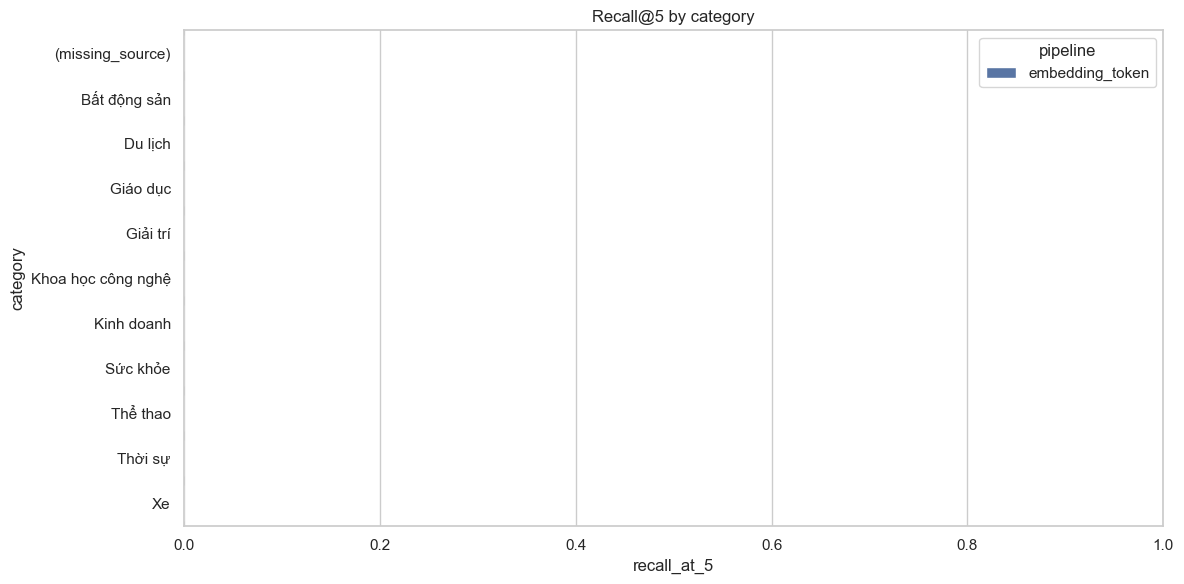

In [31]:
def hit_at_k(row,k=5):
    gold=set(map(str,as_list(row.get('gold_articles',row.get('source_article_ids',[])))))
    cands=row.get('reranked_candidates') or row.get('candidates') or []
    retrieved=set(str(c.get('article_id')) for c in cands[:k])
    return bool(gold & retrieved) if gold else np.nan
def gold_category(row):
    gold=as_list(row.get('gold_articles',row.get('source_article_ids',[])))
    cats=sorted({id_to_category.get(str(x),'(missing_source)') for x in gold})
    return '; '.join(cats) if cats else '(no_gold)'
retrieval_files={'embedding_token':ROOT/'src'/'embedding'/'output'/'per_query_token.jsonl','rerank_bge_token':ROOT/'src'/'re-ranker'/'output_Rerank'/'rerank_token_bge_top5.jsonl'}
recall_tables=[]
for name,path in retrieval_files.items():
    if not path.exists(): print('Missing:',path); continue
    df=pd.DataFrame([json.loads(line) for line in path.read_text(encoding='utf-8').splitlines() if line.strip()])
    df['category']=df.apply(gold_category,axis=1); df['hit_at_5']=df.apply(hit_at_k,axis=1)
    summary=df.groupby('category')['hit_at_5'].agg(questions='count',recall_at_5='mean').reset_index(); summary['pipeline']=name; recall_tables.append(summary)
recall_by_category=pd.concat(recall_tables,ignore_index=True) if recall_tables else pd.DataFrame()
if not recall_by_category.empty:
    recall_by_category['recall_at_5']=recall_by_category['recall_at_5'].round(3)
    display(recall_by_category.sort_values(['pipeline','recall_at_5','category']))
    out=ROOT/'reports'/'eda_outputs'; out.mkdir(parents=True,exist_ok=True)
    recall_by_category.to_csv(out/'recall_at5_by_category.csv',index=False)
    plt.figure(figsize=(12,6)); sns.barplot(data=recall_by_category,y='category',x='recall_at_5',hue='pipeline')
    plt.title('Recall@5 by category'); plt.xlim(0,1); plt.tight_layout()